In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from functions import clean_data, split_data
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

In [3]:
X, Y = clean_data("claims_train.csv")
X_train, X_valid, y_train, y_valid = split_data(X, Y, test_size=0.20)
X_test, y_test = clean_data("claims_test.csv")

In [ ]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 20],
    'min_samples_leaf': [50, 75, 100, 125],
    'max_features': ['sqrt', 0.5, 0.7]
}

cv = KFold(n_splits=3, shuffle=True, random_state=42)
rf_model = RandomForestRegressor(random_state=42, n_jobs=-1)

grid = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=cv,
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)
grid.fit(X_train, y_train)

best_params = grid.best_params_

In [ ]:
# best_params = {
#     'n_estimators': 100,
#     'max_depth': 10,
#     'min_samples_leaf': 50,
#     'max_features': 0.7
# }

In [5]:
best_rf = RandomForestRegressor(
    **best_params,
    random_state=42,
    n_jobs=-1
)
best_rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,50
,min_weight_fraction_leaf,0.0
,max_features,0.7
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [13]:
def mse(model, X, y):
    preds = model.predict(X)
    return mean_squared_error(y, preds)

In [14]:
mse_rf_best_train = mse(best_rf, X_train, y_train)
mse_rf_best_val = mse(best_rf, X_valid, y_valid)
mse_rf_best_test = mse(best_rf, X_test, y_test)


print("Summary:")
print(f"Best RF hyperparameters : {best_params}")
print("Train MSE:", mse_rf_best_train)
print("Validation MSE:", mse_rf_best_val)
print("Test MSE:", mse_rf_best_test)

Summary:
Best RF hyperparameters : {'n_estimators': 100, 'max_depth': 10, 'min_samples_leaf': 50, 'max_features': 0.7}
Train MSE: 0.054393994305327764
Validation MSE: 0.053588312480398574
Test MSE: 0.05777177629860315


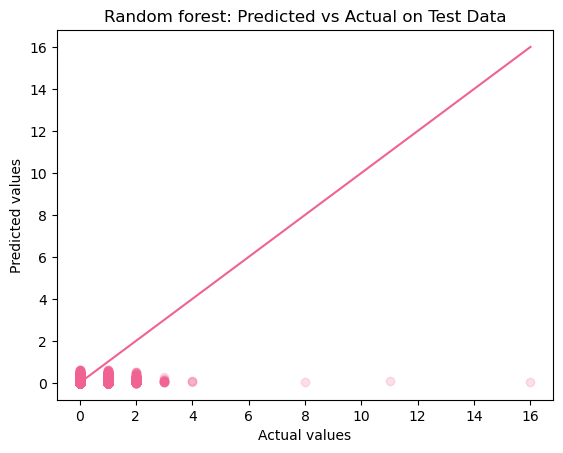

In [ ]:
plt.figure()
plt.scatter(y_test, best_rf.predict(X_test), alpha=0.2, color='#F06292')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], color='#F06292')
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.title("Random forest: Predicted vs Actual on Test Data")
plt.savefig("Random forest Predicted vs Actual on Test Data.png", dpi=300, bbox_inches='tight')


plt.show()

In [6]:
df = pd.read_csv('claims_train.csv')

Y = df['ClaimNb']

df['VehIsregular'] = (df['VehGas'] == 'Regular').astype(int)

df = df.drop(columns= ['VehGas', 'IDpol', 'ClaimNb'])

def letter_to_index(letter):
    return ord(letter.upper()) - ord('A')

df['Area'] = df['Area'].apply(letter_to_index)

df['Exposure'] = df['Exposure'].apply(lambda x: x - 1 if x > 1 else x)

df = pd.get_dummies(df)

importances = pd.Series(
    best_rf.feature_importances_,
    index= df.columns
).sort_values(ascending=False)

top10 = importances.head(10)

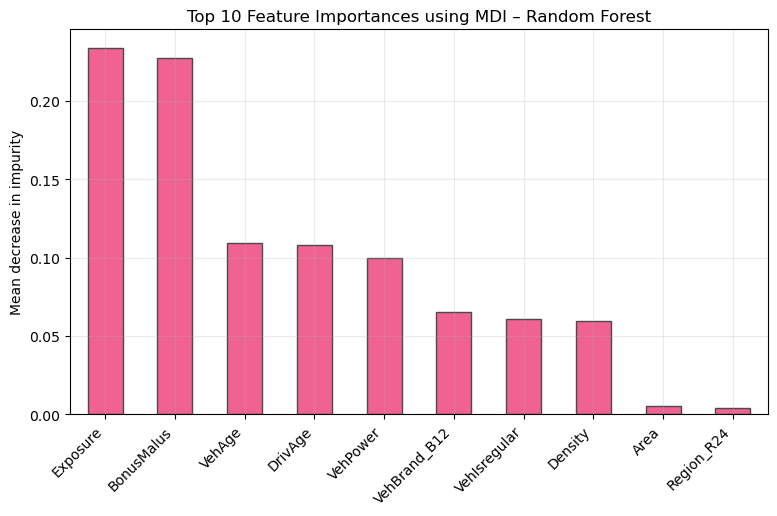

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
top10.plot(
    kind="bar",
    ax=ax,
    color='#F06292',
    edgecolor="#4A4A4A"
)

ax.set_title("Top 10 Feature Importances using MDI – Random Forest")
ax.set_ylabel("Mean decrease in impurity")
ax.set_xlabel("")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.grid(True, alpha=0.25)

plt.savefig("Top 10 Feature Importances using MDI – Random Forest.png", dpi=300, bbox_inches='tight')